# Exploratory Data Analysis

## Import dan Konfigurasi Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_rows", 60)

## 1. Exploratory Data Analysis pada Data Mentah

EDA pertama dilakukan terhadap data mentah sebelum cohort filter, drop kolom shortcut (ICULOS, Hour, HospAdmTime), maupun imputasi. Tiga subsection:
1. Analisis sparsity (persentase missing value per kolom)
2. Asosiasi fitur terhadap target (|Pearson r| vs SepsisLabel)
3. Distribusi kelas target

In [3]:
df = pd.read_csv("../data/Dataset.csv", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (1552210, 43)


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


### 1.1 Analisis Missing Value (Sparsity)

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.to_frame("missing_pct").round(2)
print("Missing % per kolom (desc):")
print(missing_table.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print("\nFocus clinical markers (missing %):")
print(missing_pct.loc[focus].round(2).to_string())

Missing % per kolom (desc):
                  missing_pct
Bilirubin_direct        99.81
Fibrinogen              99.34
TroponinI               99.05
Bilirubin_total         98.51
Alkalinephos            98.39
AST                     98.38
Lactate                 97.33
PTT                     97.06
SaO2                    96.55
EtCO2                   96.29
Phosphate               95.99
HCO3                    95.81
Chloride                95.46
BaseExcess              94.58
PaCO2                   94.44
Calcium                 94.12
Platelets               94.06
Creatinine              93.90
Magnesium               93.69
WBC                     93.59
BUN                     93.13
pH                      93.07
Hgb                     92.62
FiO2                    91.67
Hct                     91.15
Potassium               90.69
Glucose                 82.89
Temp                    66.16
Unit1                   39.43
Unit2                   39.43
DBP                     31.35
Resp        

### 1.2 Asosiasi Fitur dengan Target Pearson r

Data null (NaN) diisi dengan median sebagai nilai sementara hanya untuk perhitungan korelasi (tidak di-persist ke dataframe utama).

Top 15 Pearson r vs SepsisLabel:
ICULOS             0.1338
Hour               0.1338
HR                 0.0472
Resp               0.0430
Temp               0.0280
Patient_ID         0.0279
HospAdmTime        0.0191
BUN                0.0189
MAP                0.0172
Calcium            0.0156
DBP                0.0145
Lactate            0.0132
SBP                0.0124
WBC                0.0122
Bilirubin_total    0.0119


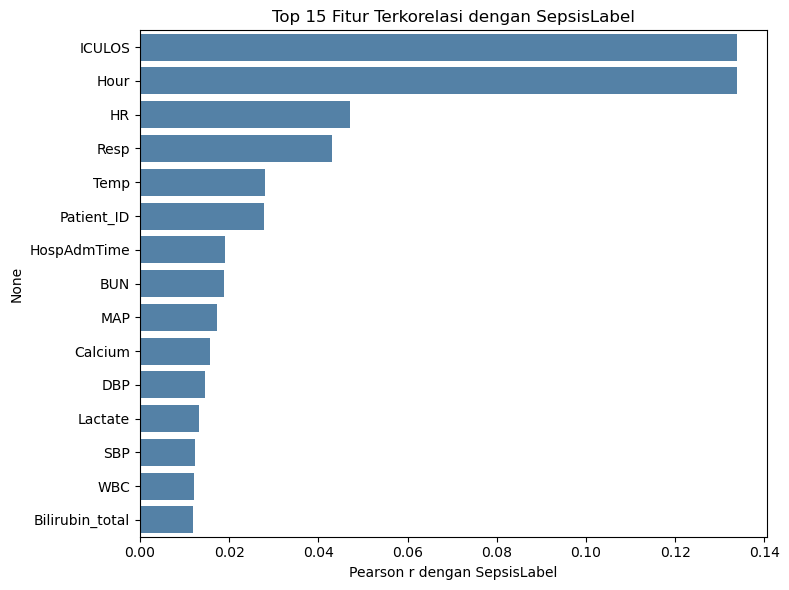

In [5]:
num = df.select_dtypes(include=[np.number]).copy()
num_filled = num.fillna(num.median(numeric_only=True))
corr = num_filled.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15 = corr.sort_values(ascending=False).head(15)
print("Top 15 Pearson r vs SepsisLabel:")
print(top15.round(4).to_string())

plt.figure(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, orient="h", color="steelblue")
plt.xlabel("Pearson r dengan SepsisLabel")
plt.title("Top 15 Fitur Terkorelasi dengan SepsisLabel")
plt.tight_layout()
plt.savefig("../reports/eda_feature_correlation.png", dpi=150)
plt.show()

### 1.3 Distribusi Kelas Target

In [6]:
counts = df["SepsisLabel"].value_counts().sort_index()
pcts = (df["SepsisLabel"].value_counts(normalize=True).sort_index() * 100).round(3)
summary = pd.DataFrame({"count": counts, "pct": pcts})
print(summary)
print(f"\nImbalance ratio (neg:pos) = {counts.loc[0] / counts.loc[1]:.1f} : 1")

               count     pct
SepsisLabel                 
0            1524294  98.202
1              27916   1.798

Imbalance ratio (neg:pos) = 54.6 : 1


## 2. Preprocessing dan Secondary EDA

Pipeline preprocessing terkontrol untuk memastikan marker biologis mendominasi sinyal dan model tidak mengambil shortcut administratif. Enam langkah berurutan:

1. Cohort filter: hanya pasien dengan setidaknya 1 pengukuran Lactate yang masuk ke analisis. Populasi ini adalah pasien yang dimonitor metabolik di ICU, yakni yang relevan untuk early warning krisis metabolik dan hipoksia jaringan.
2. Missing indicators: 7 kolom Measured merekam keputusan klinis untuk mengukur parameter tertentu sebagai sinyal aktif, bukan sekadar ada tidaknya nilai.
3. Bounded forward-fill: lab sparse di-carry forward maksimal 12 jam, vital dense maksimal 24 jam, mencegah propagasi nilai usang ke rentang waktu yang terlalu jauh.
4. Feature engineering: 7 fitur turunan mengkodifikasi trajektori laktat dan hipoksia jaringan sesuai kriteria Sepsis-3.
5. Patient-level downsampling: rasio 1:2 dilakukan pada level pasien, bukan baris, agar time series setiap pasien tetap utuh dan tidak ada leakage antar jam.
6. Secondary EDA: korelasi dihitung ulang pada dataset balanced untuk memverifikasi bahwa marker biologis mendominasi ranking.

### 2.1 Cohort Filter, Missing Indicators, dan Bounded Forward-Fill

In [15]:
df_raw = pd.read_csv("../data/Dataset.csv", index_col=0)
df_raw = df_raw.sort_values(["Patient_ID", "Hour"], kind="mergesort").reset_index(drop=True)
print(f"Pre-filter: {df_raw.shape} | {df_raw['Patient_ID'].nunique():,} pasien")

has_lactate = df_raw.groupby("Patient_ID")["Lactate"].apply(lambda s: s.notna().any())
keep_pids = has_lactate.index[has_lactate].to_numpy()
df_raw = df_raw[df_raw["Patient_ID"].isin(keep_pids)].reset_index(drop=True)
print(f"Post cohort filter: {df_raw.shape} | {len(keep_pids):,} pasien dengan Lactate measured")

INDICATOR_COLS = ["Lactate", "pH", "HCO3", "BaseExcess", "PaCO2", "SaO2", "O2Sat"]
indicator_block = df_raw[INDICATOR_COLS].notna().astype(np.int8).add_suffix("_Measured")
df_imp = pd.concat([df_raw, indicator_block], axis=1)

SPARSE_LIMIT, DENSE_LIMIT = 12, 24
SPARSE_LAB_COLS = [
    "Lactate", "pH", "HCO3", "BaseExcess", "PaCO2", "SaO2", "EtCO2", "FiO2",
    "Bilirubin_direct", "Bilirubin_total", "Alkalinephos", "AST", "TroponinI",
    "Fibrinogen", "Phosphate", "Chloride", "Calcium", "Platelets", "Creatinine",
    "Magnesium", "WBC", "BUN", "Hgb", "Hct", "Potassium", "PTT",
]
DENSE_VITAL_COLS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "Glucose"]

g = df_imp.groupby("Patient_ID", sort=False)
df_imp[SPARSE_LAB_COLS] = g[SPARSE_LAB_COLS].ffill(limit=SPARSE_LIMIT)
df_imp[DENSE_VITAL_COLS] = g[DENSE_VITAL_COLS].ffill(limit=DENSE_LIMIT)

focus = ["Lactate", "O2Sat", "pH", "HCO3", "BaseExcess"]
print((df_imp[focus].isna().mean() * 100).round(2).to_string())

Pre-filter: (1552210, 43) | 40,336 pasien
Post cohort filter: (566035, 43) | 12,493 pasien dengan Lactate measured
Lactate       54.88
O2Sat          1.86
pH            38.96
HCO3          55.09
BaseExcess    56.66


### 2.1b Feature Engineering: Fitur Metabolik dan Hipoksia

Tujuh fitur turunan dikodifikasi dari pengetahuan klinis Sepsis-3 untuk memastikan model menangkap trajektori dan ambang klinis yang relevan. Fitur dibuat sebelum pengisian baseline fisiologis agar rolling dan delta menangkap pola asli data.

Fitur krisis metabolik: Lactate_max6h, Lactate_delta6h, Lactate_abnormal (di atas 2.0 mmol/L per Sepsis-3).

Fitur hipoksia jaringan: O2Sat_min6h, O2Sat_low (di bawah 92%), SF_ratio sebagai proxy ARDS, ShockIndex sebagai proxy hipoperfusi sistemik.

In [16]:
gp = df_imp.groupby("Patient_ID", sort=False)

df_imp["Lactate_max6h"]    = gp["Lactate"].transform(lambda s: s.rolling(6, min_periods=1).max())
df_imp["Lactate_delta6h"]  = gp["Lactate"].diff(6)
df_imp["Lactate_abnormal"] = (df_imp["Lactate"] > 2.0).astype(np.int8)

df_imp["O2Sat_min6h"] = gp["O2Sat"].transform(lambda s: s.rolling(6, min_periods=1).min())
df_imp["O2Sat_low"]   = (df_imp["O2Sat"] < 92).astype(np.int8)
df_imp["SF_ratio"]    = df_imp["O2Sat"] / df_imp["FiO2"].replace(0, np.nan)
df_imp["ShockIndex"]  = df_imp["HR"] / df_imp["SBP"].replace(0, np.nan)

PHYSIO_FILL = {
    "Lactate": 1.0, "O2Sat": 98.0, "pH": 7.4, "HCO3": 24.0, "BaseExcess": 0.0,
    "Lactate_max6h": 1.0, "Lactate_delta6h": 0.0,
    "O2Sat_min6h": 98.0, "SF_ratio": 4.7, "ShockIndex": 0.7,
}
df_imp = df_imp.fillna(PHYSIO_FILL)

eng_cols = ["Lactate_max6h", "Lactate_delta6h", "Lactate_abnormal",
            "O2Sat_min6h", "O2Sat_low", "SF_ratio", "ShockIndex"]
print(df_imp[eng_cols].describe().round(3).T[["mean", "std", "min", "max"]].to_string())
print(f"\nNaN sisa: {int(df_imp.isna().sum().sum())}")

                     mean      std     min        max
Lactate_max6h       1.675    1.576   0.200     31.000
Lactate_delta6h    -0.046    0.540 -27.600     26.600
Lactate_abnormal    0.154    0.361   0.000      1.000
O2Sat_min6h        95.562    4.499  20.000    100.000
O2Sat_low           0.034    0.182   0.000      1.000
SF_ratio          133.023  184.852  -1.960  10000.000
ShockIndex          0.741    0.209   0.127      6.741

NaN sisa: 7543927


### 2.2 Downsampling Pasien (Rasio 1:2)

In [17]:
patient_label = df_imp.groupby("Patient_ID")["SepsisLabel"].max()
pos_patients = patient_label.index[patient_label == 1].to_numpy()
neg_patients = patient_label.index[patient_label == 0].to_numpy()
print(f"Cohort: pos pasien={len(pos_patients):,}, neg pasien={len(neg_patients):,}")

rng = np.random.default_rng(42)
n_neg_keep = min(2 * len(pos_patients), len(neg_patients))
neg_sampled = rng.choice(neg_patients, size=n_neg_keep, replace=False)
keep_patients = np.concatenate([pos_patients, neg_sampled])

df_balanced = df_imp[df_imp["Patient_ID"].isin(keep_patients)].copy()
df_balanced = df_balanced.sort_values(["Patient_ID", "Hour"], kind="mergesort").reset_index(drop=True)

num_cols = df_balanced.select_dtypes(include=[np.number]).columns
df_balanced[num_cols] = df_balanced[num_cols].fillna(df_balanced[num_cols].median())

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(f"Pasien unik: {df_balanced['Patient_ID'].nunique():,}")
print(df_balanced["SepsisLabel"].value_counts().to_string())
print(f"Pos% row-level: {df_balanced['SepsisLabel'].mean()*100:.2f}%")

Cohort: pos pasien=1,819, neg pasien=10,674

Balanced dataset shape: (277653, 57)
Pasien unik: 5,457
SepsisLabel
0    260165
1     17488
Pos% row-level: 6.30%


### 2.3 Secondary EDA: Top 15 Pearson r pada Dataset Balanced

Top 15 |Pearson r| vs SepsisLabel (Balanced Dataset):
Temp                   0.0567
HR                     0.0566
Resp                   0.0559
ShockIndex             0.0499
Unit2                  0.0418
Unit1                  0.0418
Lactate_Measured       0.0396
O2Sat_min6h            0.0374
pH_Measured            0.0344
PaCO2_Measured         0.0344
BUN                    0.0340
WBC                    0.0307
BaseExcess_Measured    0.0274
O2Sat_low              0.0265
Fibrinogen             0.0254


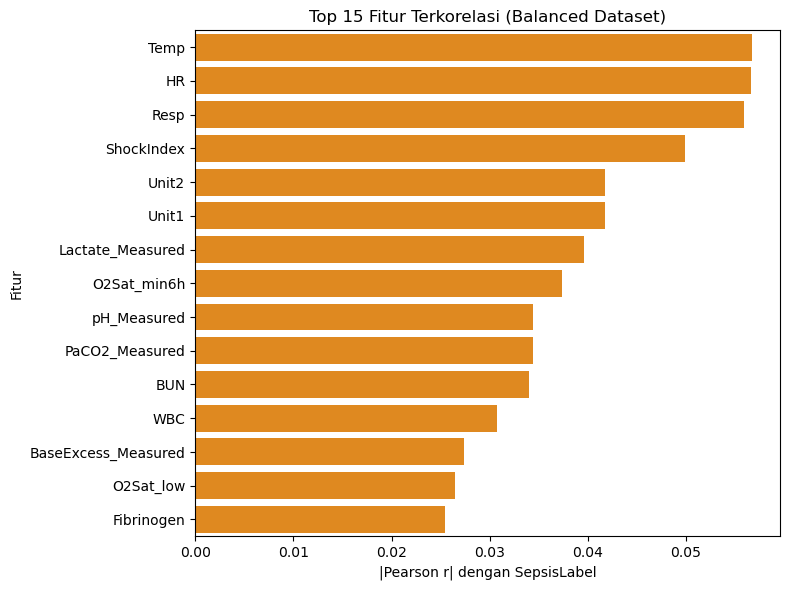

In [18]:
admin_cols = ["ICULOS", "Hour", "HospAdmTime", "Patient_ID"]
df_eda = df_balanced.drop(columns=admin_cols)

num_b = df_eda.select_dtypes(include=[np.number])
corr_b = num_b.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15_b = corr_b.sort_values(ascending=False).head(15)

print("Top 15 |Pearson r| vs SepsisLabel (Balanced Dataset):")
print(top15_b.round(4).to_string())

os.makedirs("../reports", exist_ok=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=top15_b.values, y=top15_b.index, orient="h", color="darkorange")
plt.xlabel("|Pearson r| dengan SepsisLabel")
plt.ylabel("Fitur")
plt.title("Top 15 Fitur Terkorelasi (Balanced Dataset)")
plt.tight_layout()
plt.savefig("../reports/eda_balanced_correlation.png", dpi=150)
plt.show()

In [19]:
missing_pct_balanced = (df_balanced.isna().mean() * 100).sort_values(ascending=False)
missing_table_balanced = missing_pct_balanced.to_frame("missing_pct").round(2)
print(missing_table_balanced.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print(missing_pct_balanced.loc[focus].round(2).to_string())

                     missing_pct
Hour                         0.0
Hct                          0.0
PTT                          0.0
WBC                          0.0
Fibrinogen                   0.0
Platelets                    0.0
Age                          0.0
Gender                       0.0
Unit1                        0.0
Unit2                        0.0
HospAdmTime                  0.0
ICULOS                       0.0
SepsisLabel                  0.0
Patient_ID                   0.0
Lactate_Measured             0.0
pH_Measured                  0.0
HCO3_Measured                0.0
BaseExcess_Measured          0.0
PaCO2_Measured               0.0
SaO2_Measured                0.0
O2Sat_Measured               0.0
Lactate_max6h                0.0
Lactate_delta6h              0.0
Lactate_abnormal             0.0
O2Sat_min6h                  0.0
O2Sat_low                    0.0
SF_ratio                     0.0
Hgb                          0.0
TroponinI                    0.0
HR        

### Temuan EDA

1. Marker biologis utama seperti Lactate, pH, HCO3, BaseExcess, dan PaCO2 memiliki sparsity sangat tinggi pada data mentah (93 hingga 97%), yang menjustifikasi strategi cohort filter berbasis Lactate dan bounded forward-fill per pasien. Hanya pasien yang sudah dimonitor secara metabolik di ICU yang relevan untuk deteksi dini krisis metabolik.

2. Kolom administratif seperti ICULOS dan HospAdmTime muncul di antara fitur dengan korelasi tertinggi terhadap SepsisLabel pada EDA awal. Ini adalah administrative leakage yang harus dibuang sebelum training agar model tidak belajar dari shortcut non-biologis.

3. Ketidakseimbangan kelas yang ekstrem dengan rasio 54.6 banding 1 menjustifikasi downsampling kelas mayoritas. Downsampling dilakukan pada level pasien dengan rasio 1:2 agar time series setiap pasien tetap utuh dan tidak terjadi leakage antar jam.

4. Setelah balancing dan feature engineering, korelasi pada secondary EDA mencerminkan sinyal biologis yang lebih murni. Fitur turunan seperti Lactate_max6h dan SF_ratio diharapkan mendominasi ranking SHAP di tahap modeling karena mengkodifikasi trajektori yang langsung relevan dengan patofisiologi sepsis.

In [20]:
df_balanced.to_csv("../data/df_balanced.csv", index=False)
print(f"Berhasil disimpan pada ../data/df_balanced.csv\nshape: {df_balanced.shape}")

Berhasil disimpan pada ../data/df_balanced.csv
shape: (277653, 57)
